In [ ]:
import os
import re
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import pickle

def get_dirs(pattern, root_dir='../runs'):
    matching_dirs = []

    for dirpath, _, _ in os.walk(root_dir):
        rel_path = os.path.relpath(dirpath, root_dir)
        if pattern.search(rel_path):
            matching_dirs.append(os.path.join(root_dir, rel_path))

    print("Matched directories:")
    for path in matching_dirs:
        print(path)
    
    return matching_dirs

def _find_event_file(log_dir: str) -> str:
    """
    Given a directory `log_dir` (which should contain one or more
    'events.out.tfevents.*' files), return the first matching filename.
    Raises FileNotFoundError if no event file is found.
    """
    for fname in os.listdir(log_dir):
        if "events.out.tfevents" in fname:
            return os.path.join(log_dir, fname)
    raise FileNotFoundError(f"No TensorBoard event file found in {log_dir!r}.")

def extract_scalars_from_event(event_file: str, tag: str):
    """
    Read one TensorBoard event file and pull out all (step, value, wall_time) triples
    for the scalar `tag`. Returns three parallel lists: (steps, values, wall_times).

    Raises:
        ValueError if `tag` is not present in that event file.
    """
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={"scalars": 0}  # 0 → load all scalar events
    )
    ea.Reload()

    available_tags = ea.Tags().get("scalars", [])
    if tag not in available_tags:
        raise ValueError(
            f"Tag {tag!r} not found in {os.path.basename(event_file)}. "
            f"Available scalar tags are: {available_tags}"
        )

    events = ea.Scalars(tag)
    steps      = [e.step      for e in events]
    values     = [e.value     for e in events]
    wall_times = [e.wall_time for e in events]
    return steps, values, wall_times

def _parse_seed_from_dir(dirpath: str) -> int:
    """
    Given a path that ends in '_s<digit>' (e.g. '..._s2/tensorboard_logs'),
    return the integer seed. Raises ValueError if no '_sN' is found.
    """
    m = re.search(r"_s([0-9]+)(?:/|$)", dirpath)
    if not m:
        raise ValueError(f"Cannot find a seed in directory name: {dirpath!r}")
    return int(m.group(1))

def collect_scalar(matching_dirs, tag):
    """
    For each directory in matching_dirs, locate the TensorBoard event file,
    extract (steps, values) for `tag`, and store them in a dict keyed by seed.
    Verifies all seeds share the same 'steps' array; if not, raises an error.

    Returns:
        data_dict: Dict[int → (np.ndarray steps, np.ndarray values)]
    """
    data_dict = {}

    for run_dir in matching_dirs:

        event_path = _find_event_file(run_dir)   # find 'events.out.tfevents.*' in run_dir
        steps, values, _ = extract_scalars_from_event(event_path, tag)

        steps_arr  = np.array(steps, dtype=int)
        values_arr = np.array(values, dtype=float)

        data_dict[run_dir] = (steps_arr, values_arr)

    return data_dict

def _collect_scalar_over_seeds(matching_dirs, tag):
    """
    For each directory in matching_dirs, locate the TensorBoard event file,
    extract (steps, values) for `tag`, and store them in a dict keyed by seed.
    Verifies all seeds share the same 'steps' array; if not, raises an error.

    Returns:
        data_dict: Dict[int → (np.ndarray steps, np.ndarray values)]
    """
    data_dict = {}
    common_steps = None

    for run_dir in matching_dirs:
        seed = _parse_seed_from_dir(run_dir)

        event_path = _find_event_file(run_dir)   # find 'events.out.tfevents.*' in run_dir
        steps, values, _ = extract_scalars_from_event(event_path, tag)

        steps_arr  = np.array(steps, dtype=int)
        values_arr = np.array(values, dtype=float)

        if common_steps is None:
            common_steps = steps_arr
        else:
            # enforce that steps match exactly
            if not np.array_equal(common_steps, steps_arr):
                raise RuntimeError(
                    f"Step arrays do not match for seed {seed}. "
                    f"Got shape {steps_arr.shape}, expected {common_steps.shape}."
                )

        data_dict[seed] = (steps_arr, values_arr)

    return data_dict

def compute_mean_std(data_dict):
    """
    Given data_dict: {seed → (steps, values_array)}, extract all values
    into one 2D array of shape (num_seeds, num_steps) and compute
    mean and std along axis=0.

    Returns:
        mean_values: np.ndarray of shape (num_steps,)
        std_values:  np.ndarray of shape (num_steps,)
    """
    # Sort by seed key to keep ordering consistent
    seeds = sorted(data_dict.keys())
    values_list = [data_dict[s][1] for s in seeds]  # list of 1D arrays

    stacked = np.stack(values_list, axis=0)  # shape = (num_seeds, num_steps)
    mean_vals = np.mean(stacked, axis=0)
    std_vals  = np.std (stacked, axis=0)

    return mean_vals, std_vals

def get_loss_stats(matching_dirs):
    """
    High-level function to get:
      steps, train_mean, train_std, val_mean, val_std

    1) Collect “Loss/Train” over all seeds
    2) Collect “Loss/Validation” over all seeds
    3) Guarantee steps match
    4) Return steps + (mean/std) for both tags.

    Returns:
        steps:       np.ndarray of shape (num_steps,)
        train_mean:  np.ndarray of shape (num_steps,)
        train_std:   np.ndarray of shape (num_steps,)
        val_mean:    np.ndarray of shape (num_steps,)
        val_std:     np.ndarray of shape (num_steps,)
    """
    # 1) Collect all seeds for "Loss/Train"
    train_dict = _collect_scalar_over_seeds(matching_dirs, "Loss/Train")
    # 2) Collect all seeds for "Loss/Validation"
    val_dict   = _collect_scalar_over_seeds(matching_dirs, "Loss/Validation")

    # Both dicts have the same keys and same step arrays (validated inside _collect_…)
    # Extract any seed’s steps to use as the common axis.
    any_seed = next(iter(train_dict))
    steps = train_dict[any_seed][0]  # np.ndarray of ints

    # 3) Compute mean and std
    train_mean, train_std = compute_mean_std({s: train_dict[s] for s in train_dict})
    val_mean,   val_std   = compute_mean_std({s: val_dict[s]   for s in val_dict})

    return steps, train_mean, train_std, val_mean, val_std

def plot_loss_stats(ax, loss_stats, label, color='crimson'):
    ax1, ax2 = ax
    steps_, train_mean, train_std, val_mean, val_std = loss_stats
    steps = steps_ / 1e6
    ax1.plot(steps, train_mean,   label=label, color=color)
    ax1.fill_between(steps,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.5, color=color)
    ax1.set_title('Train')
    ax2.plot(steps, val_mean,     label=label,   color=color)
    ax2.fill_between(steps,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.5, color=color)
    ax2.set_title('Validation')

In [16]:
EUC_COLOR = 'lightcoral'
HYP_COLOR = 'crimson'

#### Shakespeare

In [14]:
with open('shakespeare_curvatures.pkl', 'rb') as file:
    shakespeare_curvatures = pickle.load(file)
    
keys = ['sh_ee', 'sh_eh_lr1', 'sh_eh_lr3', 'sh_eh_lr10', 'sh_eh_lr33']
losses = {}
for k in keys:
    pattern = re.compile(f"{k}_402K.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)
    loss_stats = get_loss_stats(matching_dirs)
    losses[k] = loss_stats

Matched directories:
../runs/05.31/68072_sh_ee_402K_s0/tensorboard_logs
../runs/05.31/68527_sh_ee_402K_s1/tensorboard_logs
../runs/05.31/68696_sh_ee_402K_s2/tensorboard_logs
../runs/05.31/68877_sh_ee_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/69397_sh_eh_lr1_402K_s0/tensorboard_logs
../runs/05.31/69665_sh_eh_lr1_402K_s1/tensorboard_logs
../runs/05.31/69908_sh_eh_lr1_402K_s2/tensorboard_logs
../runs/05.31/70154_sh_eh_lr1_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/70395_sh_eh_lr3_402K_s0/tensorboard_logs
../runs/05.31/70637_sh_eh_lr3_402K_s1/tensorboard_logs
../runs/05.31/70883_sh_eh_lr3_402K_s2/tensorboard_logs
../runs/05.31/71123_sh_eh_lr3_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/71365_sh_eh_lr10_402K_s0/tensorboard_logs
../runs/05.31/71610_sh_eh_lr10_402K_s1/tensorboard_logs
../runs/05.31/71850_sh_eh_lr10_402K_s2/tensorboard_logs
../runs/05.31/72091_sh_eh_lr10_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/72337_sh_eh_l

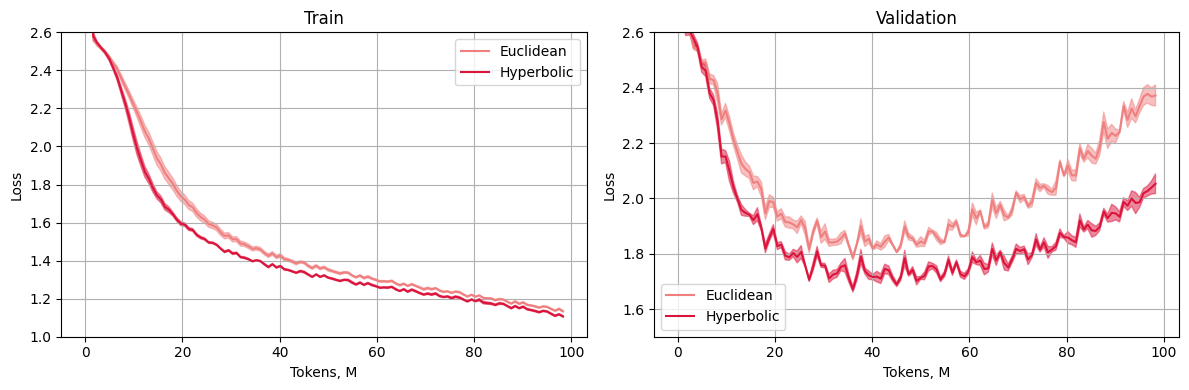

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_loss_stats(axs, losses['sh_ee'], 'Euclidean', EUC_COLOR)
plot_loss_stats(axs, losses['sh_eh_lr1'], 'Hyperbolic', HYP_COLOR)

for ax in axs:
    ax.set_xlabel("Tokens, M")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

axs[0].set_ylim([1., 2.6])
axs[1].set_ylim([1.5, 2.6])

plt.tight_layout()
plt.show()


#### Tinystories

Matched directories:
../runs/05.30/05190_tsc_ee_1.35M_s0/tensorboard_logs
../runs/05.30/11290_tsc_ee_1.35M_s1/tensorboard_logs
../runs/05.30/17393_tsc_ee_1.35M_s2/tensorboard_logs
../runs/05.30/23491_tsc_ee_1.35M_s3/tensorboard_logs
Matched directories:
../runs/05.29/67209_tsc_ee_1.35M_s0/tensorboard_logs
../runs/05.29/73302_tsc_ee_1.35M_s1/tensorboard_logs
../runs/05.29/79399_tsc_ee_1.35M_s2/tensorboard_logs
../runs/05.29/85495_tsc_ee_1.35M_s3/tensorboard_logs
Matched directories:
../runs/05.29/68488_tsc_eh_lr1_1.35M_s1/tensorboard_logs
../runs/05.29/74582_tsc_eh_lr1_1.35M_s2/tensorboard_logs
../runs/05.29/80680_tsc_eh_lr1_1.35M_s3/tensorboard_logs
../runs/05.29/62392_tsc_eh_lr1_1.35M_s0/tensorboard_logs
Matched directories:
../runs/05.30/00374_tsc_eh_lr10_1.35M_s0/tensorboard_logs
../runs/05.30/06476_tsc_eh_lr10_1.35M_s1/tensorboard_logs
../runs/05.30/12576_tsc_eh_lr10_1.35M_s2/tensorboard_logs
../runs/05.30/18677_tsc_eh_lr10_1.35M_s3/tensorboard_logs


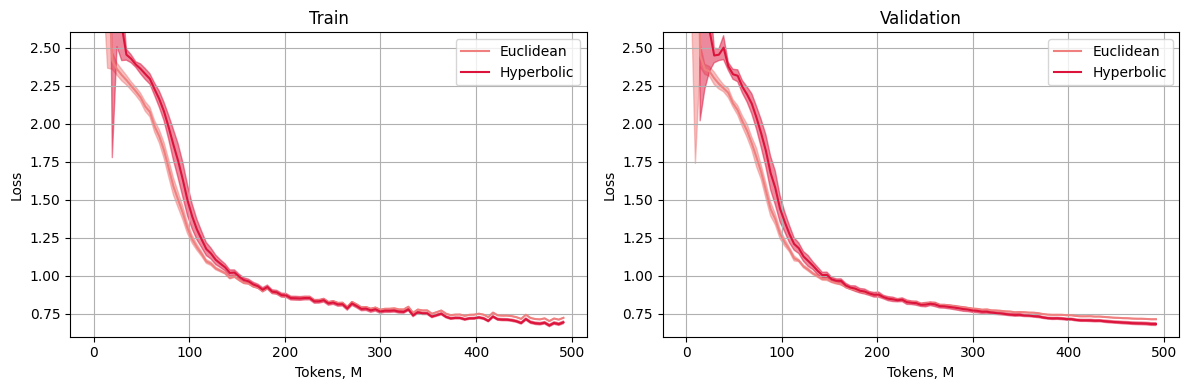

In [18]:
loss_keys = ['05.30/.*tsc_ee', '05.29/.*tsc_ee', 'tsc_eh_lr1_', 'tsc_eh_lr10']

losses = {}
for k in loss_keys:
    pattern = re.compile(f"{k}.*1.35.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)
    loss_stats = get_loss_stats(matching_dirs)
    losses[k] = loss_stats

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_loss_stats(axs, losses['05.30/.*tsc_ee'], 'Euclidean', EUC_COLOR)
plot_loss_stats(axs, losses['tsc_eh_lr1_'], 'Hyperbolic', HYP_COLOR)

for ax in axs:
    ax.set_xlabel("Tokens, M")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

axs[0].set_ylim([0.6, 2.6])
axs[1].set_ylim([0.6, 2.6])

plt.tight_layout()
plt.show()

#### Fineweb

In [19]:
loss_keys = ['05.29/65280_fwe_eh_lr1_38.3M_s0', '05.31/77818_fwe_ee_38.3M_s0']
labels = ['Hyperbolic', 'Euclidean']

losses = {}
for k, label in zip(loss_keys, labels):
    pattern = re.compile(f"{k}.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)
    train_loss = collect_scalar(matching_dirs, "Loss/Train").values()
    val_loss = collect_scalar(matching_dirs, "Loss/Validation").values()
    ld = {'Train': list(train_loss)[0], 'Val': list(val_loss)[0]}
    losses[label] = ld


Matched directories:
../runs/05.29/65280_fwe_eh_lr1_38.3M_s0/tensorboard_logs
Matched directories:
../runs/05.31/77818_fwe_ee_38.3M_s0/tensorboard_logs


In [20]:
def plot_loss(axs, losses, label, color='crimson'):
    ax1, ax2 = axs
    train, val = losses['Train'], losses['Val']
    ax1.plot(train[0] / 1e6, train[1], label=label, color=color)
    ax1.set_title('Train')
    ax2.plot(val[0] / 1e6, val[1],     label=label, color=color)
    ax2.set_title('Validation')

def plot_fineweb_loss(xlim=None, ylim=None, yscale=None):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    for c, (k, v) in zip([HYP_COLOR, EUC_COLOR], losses.items()):
        plot_loss(axs, v, k, c)

    for ax in axs:
        ax.set_xlabel("Tokens, M")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()
        if xlim:
            ax.set_xlim(xlim)
        if ylim:
            ax.set_ylim(ylim)
        if yscale:
            ax.set_yscale(yscale)

    plt.tight_layout()
    plt.show()

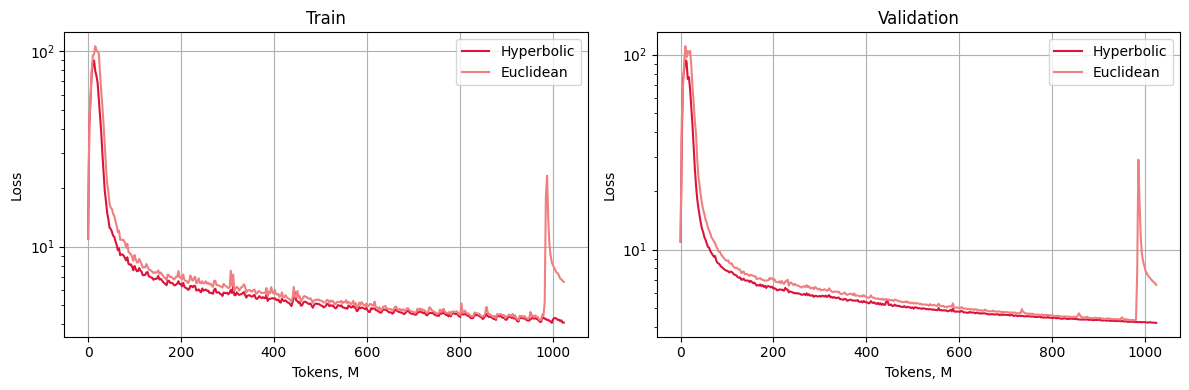

In [21]:
plot_fineweb_loss(yscale='log')

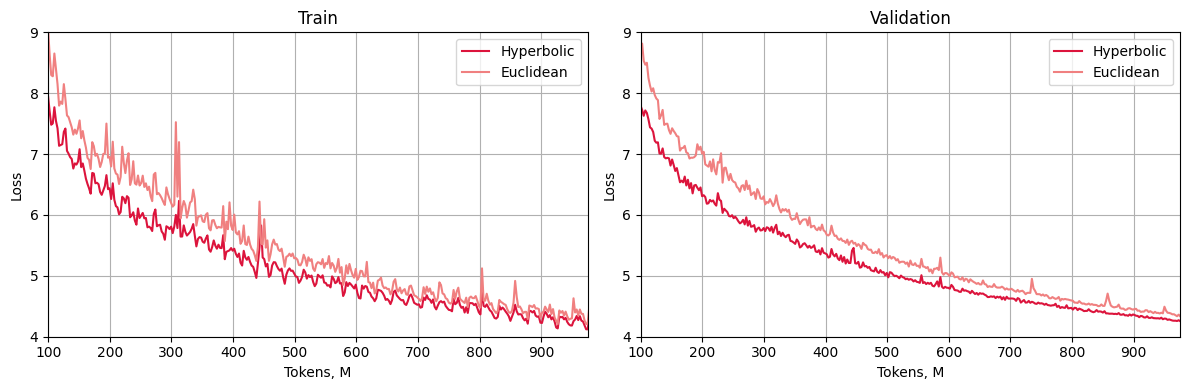

In [22]:
plot_fineweb_loss(xlim=[100, 975], ylim=[4, 9])

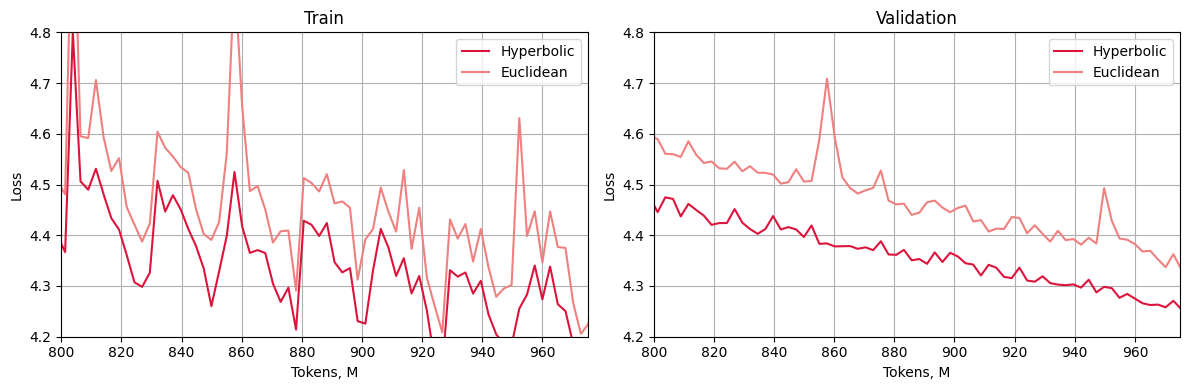

In [23]:
plot_fineweb_loss(xlim=[800, 975], ylim=[4.2, 4.8])